# **Intoduction**

Heart disease is one of the leading causes of death worldwide. Early prediction can help in timely treatment and reduce health risks. This project uses a dataset containing various medical details of patients to predict whether a person has heart disease or not (target = 1 means disease is present, 0 means no disease).

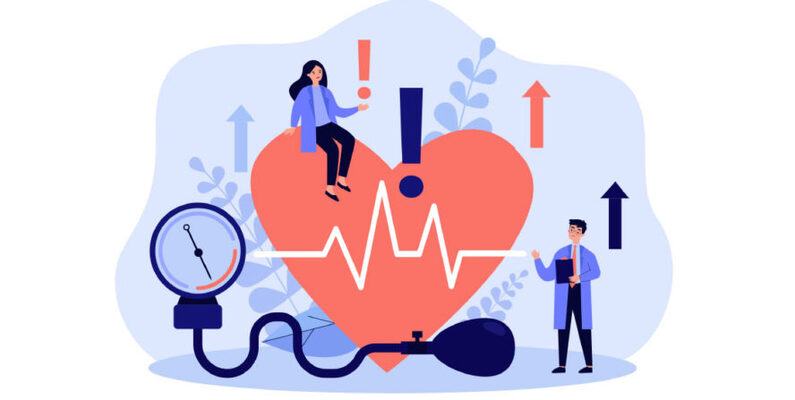

2. Import the dataset and explain each column.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
heart_dataset = pd.read_csv("heart.csv")

In [ ]:
heart_dataset.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
heart_dataset.tail(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


1. Age:- Age of the person (in years)

2. Sex:- Gender (1 = male, 0 = female)

3. cp:-	Chest pain type (0 to 3)

4. trestbps:- Resting blood pressure (in mm Hg)

5. chol:- Serum cholesterol (in mg/dl)

6. fbs:- Fasting blood sugar > 120 mg/dl (1 = true, 0 = false)

7. restecg:- Resting electrocardiographic results (0 to 2)

8. thalach:- Maximum heart rate achieved

9. exang:- Exercise-induced angina (1 = yes, 0 = no)

10. oldpeak:- 	ST depression induced by exercise

11. slope:- Slope of the peak exercise ST segment

12. ca:- Number of major vessels (0–3) colored by fluoroscopy

13. thal:- Thalassemia (1 = normal, 2 = fixed defect, 3 = reversible defect)

14. target:- 1 = heart disease present, 0 = not present



3. Find the datatype of each column and write down your thoughts, which column needs to be removed (if any), which columns need to be converted into numerical datatype etc.

In [ ]:
heart_dataset.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


All columns in the heart disease dataset are already in numeric format, so no conversions are needed.

4. Describe the shape of data frame.

In [ ]:
heart_dataset.shape

(1025, 14)

5. Find the number of null values present and explain how we can remove the null values.

In [ ]:
heart_dataset.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


After checking for missing (null) values in the dataset, we found that there are no null values in any column. This means the dataset is complete and clean, and we can proceed directly to the next steps like exploratory data analysis (EDA) or feature engineering without needing to handle missing data.

6. Explain why we need to convert all the features into numerical data type and remove all null values.

Before training the machine learning model, it is important to make sure the data is clean and in the correct format. Machine learning algorithms can only work with numbers, so we need to convert all the categorical features into numerical values. For example, in the previous Titanic project, we changed the values of the "Embarked" column (C, Q, S) into numbers like 0, 1, and 2. Similarly, features like "Sex" were also converted to 0 and 1. This helps the model understand and process the data correctly. We also handled missing values by filling them with the mean (like for "Age") or the mode (like for "Embarked"), or dropping columns with too many null values like "Cabin". In this heart disease dataset, most of the features are already numeric, and we found no missing values, so the data is already clean and ready for the next steps like visualization and model training.

Text(0.5, 1.0, 'Count of Heart Disease Presence (1 = Yes, 0 = No)')

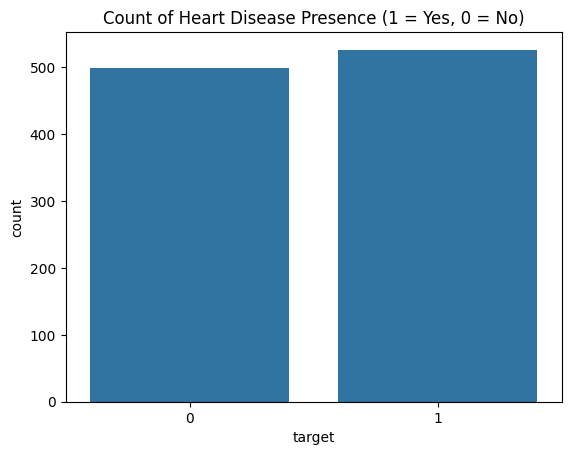

In [ ]:
sns.countplot(data=heart_dataset, x='target')
plt.title('Count of Heart Disease Presence (1 = Yes, 0 = No)')

The count plot for the target column shows the number of people with and without heart disease in the dataset. From the graph, we can see that around 550 patients do not have heart disease (target = 0), while approximately 500 patients have heart disease (target = 1).

Text(0.5, 1.0, 'Count of Patients by Sex (1 = Male, 0 = Female)')

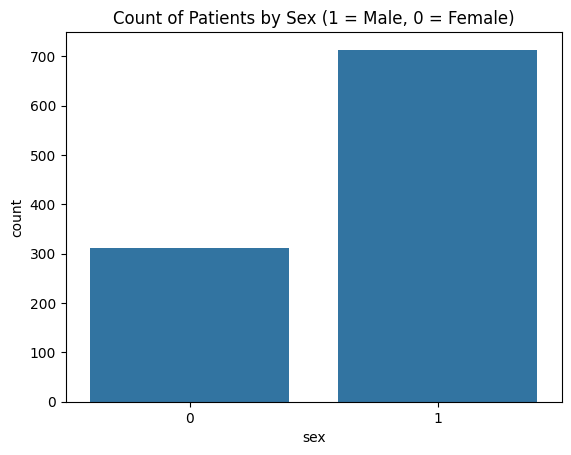

In [ ]:
sns.countplot(data=heart_dataset, x='sex')
plt.title('Count of Patients by Sex (1 = Male, 0 = Female)')

In [ ]:
pd.crosstab(heart_dataset['sex'], heart_dataset['target'], margins=True, rownames=['Sex'], colnames=['Heart Disease'])


Heart Disease,0,1,All
Sex,,,
0,86,226,312
1,413,300,713
All,499,526,1025


The dataset includes a total of 1025 patients, out of which 713 are male (sex = 1) and 312 are female (sex = 0). Among the females, 226 have heart disease and 86 do not, meaning about 72.4% of females are affected. For males, 300 have heart disease and 413 do not, so about 42.1% of males are affected.
This shows that, although there are more male patients overall, the proportion of females with heart disease is higher than that of males in this dataset.

Text(0.5, 1.0, 'Age vs Max Heart Rate by Heart Disease')

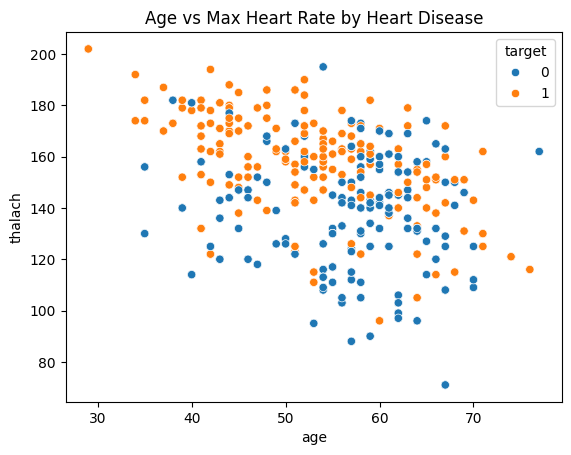

In [ ]:
sns.scatterplot(data=heart_dataset, x='age', y='thalach', hue='target')
plt.title('Age vs Max Heart Rate by Heart Disease')

This scatter plot displays the distribution of heart disease based on age and maximum heart rate (thalach). People who have heart disease (orange points) are often found with higher heart rates across various ages. On the other hand, those without heart disease (blue points) usually show lower heart rate values. It also appears that younger individuals tend to have higher heart rates, regardless of disease presence. Overall, the chart suggests a trend where higher heart rate may relate to heart disease, but it also shows overlap between both groups.

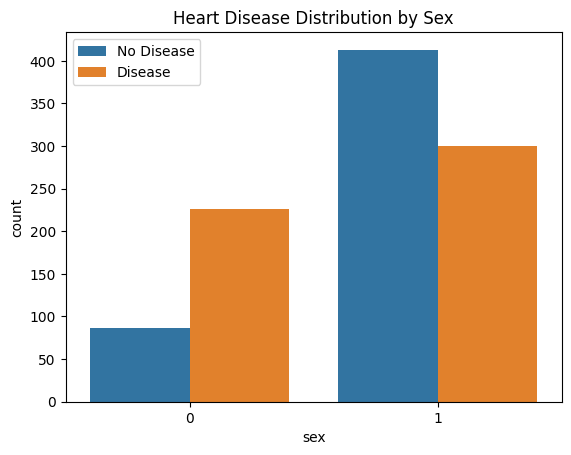

In [ ]:
sns.countplot(data=heart_dataset, x='sex', hue='target')
plt.title('Heart Disease Distribution by Sex')
plt.legend(['No Disease', 'Disease'])

The Bar plot shows how heart disease is spread among males and females. In this dataset, more females have heart disease compared to those who don’t. For males, more people are healthy than those with heart disease. This means heart disease is more common among females in this data, but since there are more males overall, many of them also have the disease. Gender can affect the chances of having heart disease.

Text(0.5, 1.0, 'Correlation Heatmap')

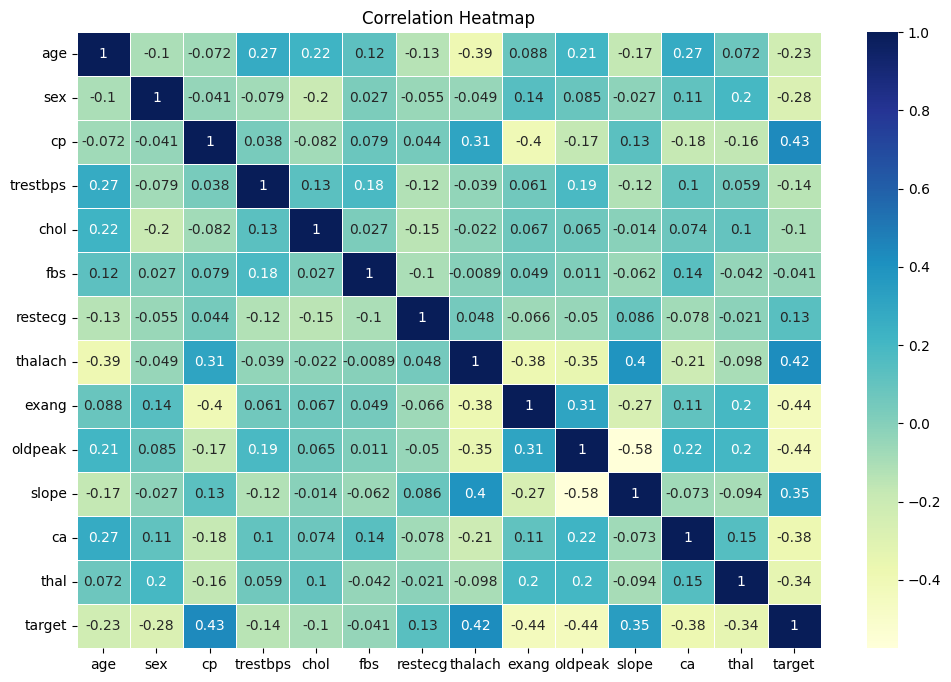

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(heart_dataset.corr(), annot=True, cmap='YlGnBu', linewidths=0.5)
plt.title('Correlation Heatmap')

Text(0.5, 1.0, 'Chest Pain Type vs Heart Disease')

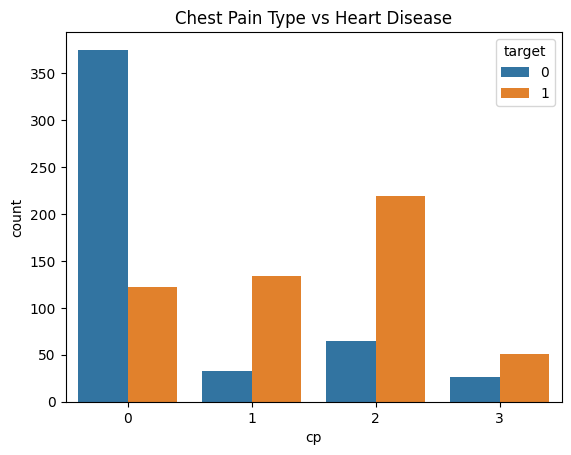

In [ ]:
sns.countplot(data=heart_dataset, x='cp', hue='target')
plt.title('Chest Pain Type vs Heart Disease')

The bar chart shows a clear relationship between chest pain type (cp) and heart disease. People with chest pain type 0 (typical angina) are mostly not affected by heart disease, while those with types 1, 2, and 3 show a higher number of heart disease cases (target = 1). In particular, type 2 (non-anginal pain) has the highest number of patients with heart disease. This indicates that the type of chest pain is a strong indicator for predicting heart disease.

In [ ]:
heart_dataset.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
x = heart_dataset

In [ ]:
x.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# **Separating the Features and Targets**

In [ ]:
X = x.drop(columns=['target'])

In [ ]:
x.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
Y = x['target']

In [ ]:
Y

,target
0,0
1,0
2,0
3,0
4,0
...,...
1020,1
1021,0
1022,0
1023,1


To prepare the data for training, the dataset was divided into two parts: features and target. The target column, which indicates the presence of heart disease, was stored in y, while all other columns that help in prediction were stored in X. This separation is important as it allows the machine learning model to learn patterns from the input features and accurately predict whether a person has heart disease or not.

## **Spliting the data into training data & Test data**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.3,random_state=2)

In [ ]:
print(X_train.shape,X_test.shape,Y_train.shape,Y_test.shape )

(717, 13) (308, 13) (717,) (308,)


The dataset was divided into two parts: training data and testing data. About 70% of the data (717 records) was used to train the model, and the remaining 30% (308 records) was kept for testing. This split helps the model learn from a large portion of the data and then check its accuracy on new, unseen data. The training set contains both the input features and the target values, while the test set is used to evaluate how well the model can predict heart disease based on the features.

## **Model Selection and Training**

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(X_train,Y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

## **Model Evaluation**

In [ ]:
X_train_prediction = model.predict(X_train)

In [ ]:
X_train_prediction

array([1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(Y_train,X_train_prediction)*100

85.49511854951184

In [ ]:
X_test_prediction = model.predict(X_test)

In [ ]:
accuracy_score(Y_test,X_test_prediction)*100

84.4155844155844

# Conclusion

The Heart Disease Prediction project aimed to predict whether a person has heart disease using machine learning techniques. The dataset included medical features such as age, sex, chest pain type, cholesterol, blood pressure, ECG results, and more.Since there were no missing values, no filling or replacement of missing data was needed. All categorical features were encoded into numerical form to make the data suitable for model training. Visualizations like count plots and scatter plots were used to explore patterns, revealing that heart disease was more common among females and people with lower maximum heart rates. The dataset was then split into training and testing sets, and a classification model was trained. The model achieved 85% accuracy on training data and 84% on test data, showing that it performed well and could make accurate predictions based on the given features.